# Make a cached Quantized Latent Datset of a folder of images.


In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.image_helpers as ih
import lpips
import math, random
import os
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import einx
import random
import torchvision
from torchvision import transforms
from datetime import datetime
from hierarchical_binary_quantization.misc.image_helpers import q_out_to_rgb
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torch.utils.data import Dataset

/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
!ls data/256x256

cats_and_dogs  fantasy	mnist_grid    pokemon
dragon	       mnist	mnist_scaled  yugioh


In [3]:
dataset='dragon'
device='cpu'
autoencoder_cp = 'checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth'
batch_size = 128

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(q_out_to_rgb(aux.quant_info.quantized)[0])
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}"
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
    h = ih.html_for_images([original, latent, reconstruction])
    return h, original, latent, reconstruction
    

In [8]:
# import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
# import hierarchical_binary_quantization.example_autoencoder as eae
# cfg = ch.check_checkpoint(autoencoder_cp)['config']
# autoencoder = ExampleQuantizingAutoencoder(**cfg)
# optimizer=None
# load_checkpoint(autoencoder,optimizer,autoencoder_cp)
# autoencoder.eval()
# pass

import hierarchical_binary_quantization.misc as hbq_misc
cp_path = "checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth"
autoencoder = hbq_misc.checkpoint_helpers.create_from_checkpoint(ExampleQuantizingAutoencoder, cp_path)


🔄 Loading checkpoint from checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth with {'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4), 'res_blocks': (1, 2, 3, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


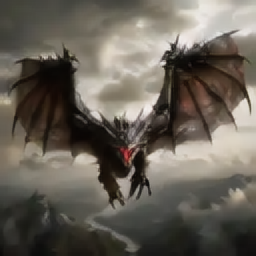

In [9]:
tf = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
ds = torchvision.datasets.ImageFolder(f'./data/256x256/{dataset}',transform=tf)
input = einx.id("C H W -> B C H W",random.choice(ds)[0],B=1).to('cpu')
output,aux = autoencoder(input)
ih.tensor_to_pil(output[0])

In [10]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import transforms

from hierarchical_binary_quantization.misc.checkpoint_helpers import load_checkpoint
from hierarchical_binary_quantization.hbq import HBQQuantizer  # adjust import path as needed
# from your_autoencoder_module import ExampleQuantizingAutoencoder

MAX_ROUNDS = 4
CKPT_PATH = autoencoder_cp
SRC_ROOT = Path(f"./data/256x256/{dataset}")
DST_ROOT = Path(f"./data/16x16x8latents/{dataset}")
DST_ROOT = Path(f"./data/32x32x8latents/{dataset}")
TARGET_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class ImageFileDataset(torch.utils.data.Dataset):
    """Like your ImageDataset, but also returns the relative path so we know
    where to write each cached file."""
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
        self.files = []
        for ext in exts:
            self.files.extend(self.root.rglob(ext))
        self.files = sorted(self.files)
        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        rel_path = path.relative_to(self.root).with_suffix(".npz")
        return img, str(rel_path)

def collate(batch):
    imgs, rel_paths = zip(*batch)
    return torch.stack(imgs), list(rel_paths)

def generate_token_cache():
    from PIL import Image  # local import so the dataset class above can use it

    transform = transforms.Compose([
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    dataset = ImageFileDataset(SRC_ROOT, transform=transform)
    loader = DataLoader(dataset, batch_size=8, shuffle=False,collate_fn=collate)
    checkpoint = torch.load(CKPT_PATH, map_location="cpu")
    conf = checkpoint["config"]  # assumes this was saved as an HBQAutoencoderConfig or dict
    autoencoder = ExampleQuantizingAutoencoder(**conf).to(DEVICE)
    autoencoder.load_state_dict(checkpoint["model_state_dict"], strict=True)
    autoencoder.eval()
    # force max rounds regardless of what the checkpoint's quantizer was set to
    autoencoder.quantizer = HBQQuantizer(n_rounds=MAX_ROUNDS)

    DST_ROOT.mkdir(parents=True, exist_ok=True)

    with torch.inference_mode():
        for imgs, rel_paths in tqdm(loader):
            imgs = imgs.to(DEVICE)
            _, aux = autoencoder(imgs)
            # aux.bit_codes shape: (B, L, H, W) -- one int per (channel, position),
            # already accumulated so bit_codes >> (MAX_ROUNDS - r) gives the r-round code
            bit_codes = aux.quant_info.bit_codes.to(torch.uint8).cpu().numpy()
            for i, rel_path in enumerate(rel_paths):
                out_path = DST_ROOT / rel_path
                out_path.parent.mkdir(parents=True, exist_ok=True)
                np.savez_compressed(out_path, bit_codes=bit_codes[i])

    print(f"Cached {len(dataset)} latents to {DST_ROOT}")

if not os.path.exists(DST_ROOT):
    generate_token_cache()

Found 10287 images.


100%|██████████| 1286/1286 [11:49<00:00,  1.81it/s]

Cached 10287 latents to data/32x32x8latents/dragon


first latent element for all cells:
 [[12 14 15 ... 14 12 13]
 [14 14  8 ...  2 12 15]
 [13 15 15 ... 11 15 14]
 ...
 [13 14 14 ... 14 14 14]
 [13 14 13 ... 15 14 14]
 [12 13 13 ... 13 13 13]]
top left latent:  [12  5  1  1  7 11  3 11]
quant bits 1, quantized.shape torch.Size([1, 8, 32, 32])


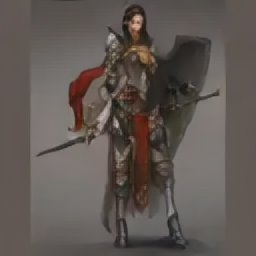

quant bits 2, quantized.shape torch.Size([1, 8, 32, 32])


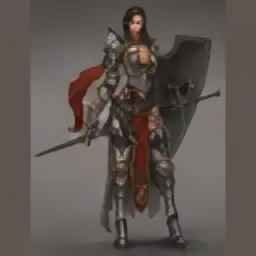

quant bits 3, quantized.shape torch.Size([1, 8, 32, 32])


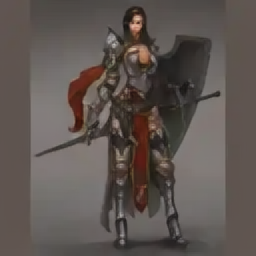

quant bits 4, quantized.shape torch.Size([1, 8, 32, 32])


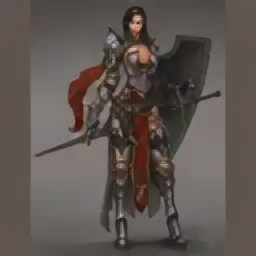

In [29]:
dataset="fantasy"
example = np.load(f'data/32x32x8latents/{dataset}/img/000002.npz')['bit_codes']
print("first latent element for all cells:\n", example[0])
print("top left latent: ", example[:,0,0])
autoencoder.to('cpu')
import IPython.display as ipd
#autoencoder.post_quant())
from hierarchical_binary_quantization.hbq import tokens_to_bit_codes, bit_codes_to_quantized_latent
et = torch.tensor(einx.id("C H W -> B C H W",example,B=1).astype(np.int8))
for quant_level in range(4):
    quantized = bit_codes_to_quantized_latent(et>>3-quant_level, n_rounds=1+quant_level)
    print(f"quant bits {quant_level+1}, quantized.shape {quantized.shape}")
    ipd.display(ih.tensor_to_pil(autoencoder.backbone.decode(autoencoder.post_quant(quantized))[0]))